# Test Case Overview

2×3 map grid: monthly-averaged forcing fields (current speed, wave height q90, wind speed q90)
for Aug and Jan, with the 6 best production-config routes overlaid per month.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean
import msgpack
import warnings

sys.path.insert(0, str(Path("..").resolve()))

from experiment_params import REPRESENTATIVE_CASES, FORCING_BASELINE
from load_results import load_results, filter_kinked_routes, get_journey_params_df, get_elite_df
from ship_routing.app.routing import RoutingResult
from ship_routing.core.data import load_currents, load_waves, load_winds

warnings.filterwarnings("ignore")

In [2]:
CASES = [
    {"month": 8, "direction": "eastward", "speed": 8, "journey": "Atlantic_forward",
     "label": "Aug E 8kn"},
    {"month": 8, "direction": "eastward", "speed": 12, "journey": "Atlantic_forward",
     "label": "Aug E 12kn"},
    {"month": 8, "direction": "eastward", "speed": 16, "journey": "Atlantic_forward",
     "label": "Aug E 16kn"},
    {"month": 8, "direction": "westward", "speed": 8, "journey": "Atlantic_backward",
     "label": "Aug W 8kn"},
    {"month": 8, "direction": "westward", "speed": 12, "journey": "Atlantic_backward",
     "label": "Aug W 12kn"},
    {"month": 8, "direction": "westward", "speed": 16, "journey": "Atlantic_backward",
     "label": "Aug W 16kn"},
    {"month": 1, "direction": "eastward", "speed": 8, "journey": "Atlantic_forward",
     "label": "Jan E 8kn"},
    {"month": 1, "direction": "eastward", "speed": 12, "journey": "Atlantic_forward",
     "label": "Jan E 12kn"},
    {"month": 1, "direction": "eastward", "speed": 16, "journey": "Atlantic_forward",
     "label": "Jan E 16kn"},
    {"month": 1, "direction": "westward", "speed": 8, "journey": "Atlantic_backward",
     "label": "Jan W 8kn"},
    {"month": 1, "direction": "westward", "speed": 12, "journey": "Atlantic_backward",
     "label": "Jan W 12kn"},
    {"month": 1, "direction": "westward", "speed": 16, "journey": "Atlantic_backward",
     "label": "Jan W 16kn"},
]

LON_MIN, LON_MAX = -85, -5
LAT_MIN, LAT_MAX = 20, 60
LON_CENT, LAT_CENT = -45.75, 40.0

FIG_DIR = "../figures"

## Load forcing data

In [3]:
data_prefix = Path("..")
spatial_bounds = (-85, -5, 25, 60)

ds_currents = load_currents(
    data_prefix / FORCING_BASELINE.currents_path,
    spatial_bounds=spatial_bounds,
)
ds_currents = ds_currents.assign(
    speed=(ds_currents.to_array() ** 2).sum("variable") ** 0.5
)
print(f"Currents: {dict(ds_currents.dims)}")

ds_waves = load_waves(
    data_prefix / FORCING_BASELINE.waves_path,
    spatial_bounds=spatial_bounds,
)
print(f"Waves: {dict(ds_waves.dims)}")

ds_winds = load_winds(
    data_prefix / FORCING_BASELINE.winds_path,
    spatial_bounds=spatial_bounds,
)
ds_winds = ds_winds.resample(time="1D").mean()
ds_winds = ds_winds.assign(
    speed=(ds_winds.to_array() ** 2).sum("variable") ** 0.5
)
print(f"Winds: {dict(ds_winds.dims)}")

Currents: {'time': 365, 'lat': 421, 'lon': 961}


Waves: {'time': 2920, 'lat': 176, 'lon': 401}


Winds: {'time': 365, 'lat': 280, 'lon': 640}


In [4]:
monthly_current_speed = ds_currents.speed.resample(time="1MS").mean()
monthly_wave_height = ds_waves.wh.resample(time="1MS").quantile(0.9)
monthly_wind_speed = ds_winds.speed.resample(time="1MS").quantile(0.9)

current_vmax = float(monthly_current_speed.quantile(0.98))
wave_vmax = float(monthly_wave_height.quantile(0.98))
wind_vmax = float(monthly_wind_speed.quantile(0.98))

print(f"Current speed range: 0 - {current_vmax:.2f} m/s")
print(f"Wave height q90 range: 0 - {wave_vmax:.2f} m")
print(f"Wind speed q90 range: 0 - {wind_vmax:.2f} m/s")

Current speed range: 0 - 0.63 m/s
Wave height q90 range: 0 - 7.33 m
Wind speed q90 range: 0 - 16.19 m/s


## Load best routes per case

In [5]:
# Load results, filter kinks, identify best route per representative case
result_files = sorted(Path("../results").glob("cost_sub*.msgpack"))
rr_dict = load_results(result_files)
rr_dict = filter_kinked_routes(rr_dict)

journey_df = get_journey_params_df(rr_dict)
elite_df = get_elite_df(rr_dict)
elite_best = elite_df[elite_df.n_elite == 0].copy()
df = journey_df.join(elite_best)

df["month"] = pd.to_datetime(df.journey_time_start.astype(str)).dt.month
df["direction"] = df.journey_name.map(
    {"Atlantic_forward": "eastward", "Atlantic_backward": "westward"}
)
df["speed"] = df.journey_speed_knots.astype(float)

# Extract route geometries from RoutingResults
best_routes = {}
for case in CASES:
    mask = (
        (df.journey_name == case["journey"])
        & (df.month == case["month"])
        & (df.speed == case["speed"])
    )
    sub = df[mask].sort_values("elite_cost_absolute")
    best_key = sub.index[0]
    rr = rr_dict[best_key]
    route = rr.elite_population.members[0].route
    lons = [wp.lon for wp in route.way_points]
    lats = [wp.lat for wp in route.way_points]
    cost_TJ = sub.iloc[0].elite_cost_absolute / 1e12
    best_routes[case["label"]] = {"lons": lons, "lats": lats, "cost_TJ": cost_TJ}
    print(f"{case['label']}: best cost = {cost_TJ:.3f} TJ (from {mask.sum()} replicas)")

records:   0%|          | 0/1052 [00:00<?, ?it/s]

135/1052 routes removed (max turning angle > 60.0°)


elite:   0%|          | 0/917 [00:00<?, ?it/s]

Aug E 8kn: best cost = 1.935 TJ (from 12 replicas)
Aug E 12kn: best cost = 4.795 TJ (from 20 replicas)
Aug E 16kn: best cost = 7.118 TJ (from 8 replicas)
Aug W 8kn: best cost = 2.994 TJ (from 15 replicas)
Aug W 12kn: best cost = 5.066 TJ (from 19 replicas)
Aug W 16kn: best cost = 8.511 TJ (from 9 replicas)
Jan E 8kn: best cost = 8.439 TJ (from 8 replicas)
Jan E 12kn: best cost = 11.654 TJ (from 9 replicas)
Jan E 16kn: best cost = 13.284 TJ (from 8 replicas)
Jan W 8kn: best cost = 6.709 TJ (from 7 replicas)
Jan W 12kn: best cost = 9.160 TJ (from 13 replicas)
Jan W 16kn: best cost = 13.449 TJ (from 10 replicas)


## Overview plot

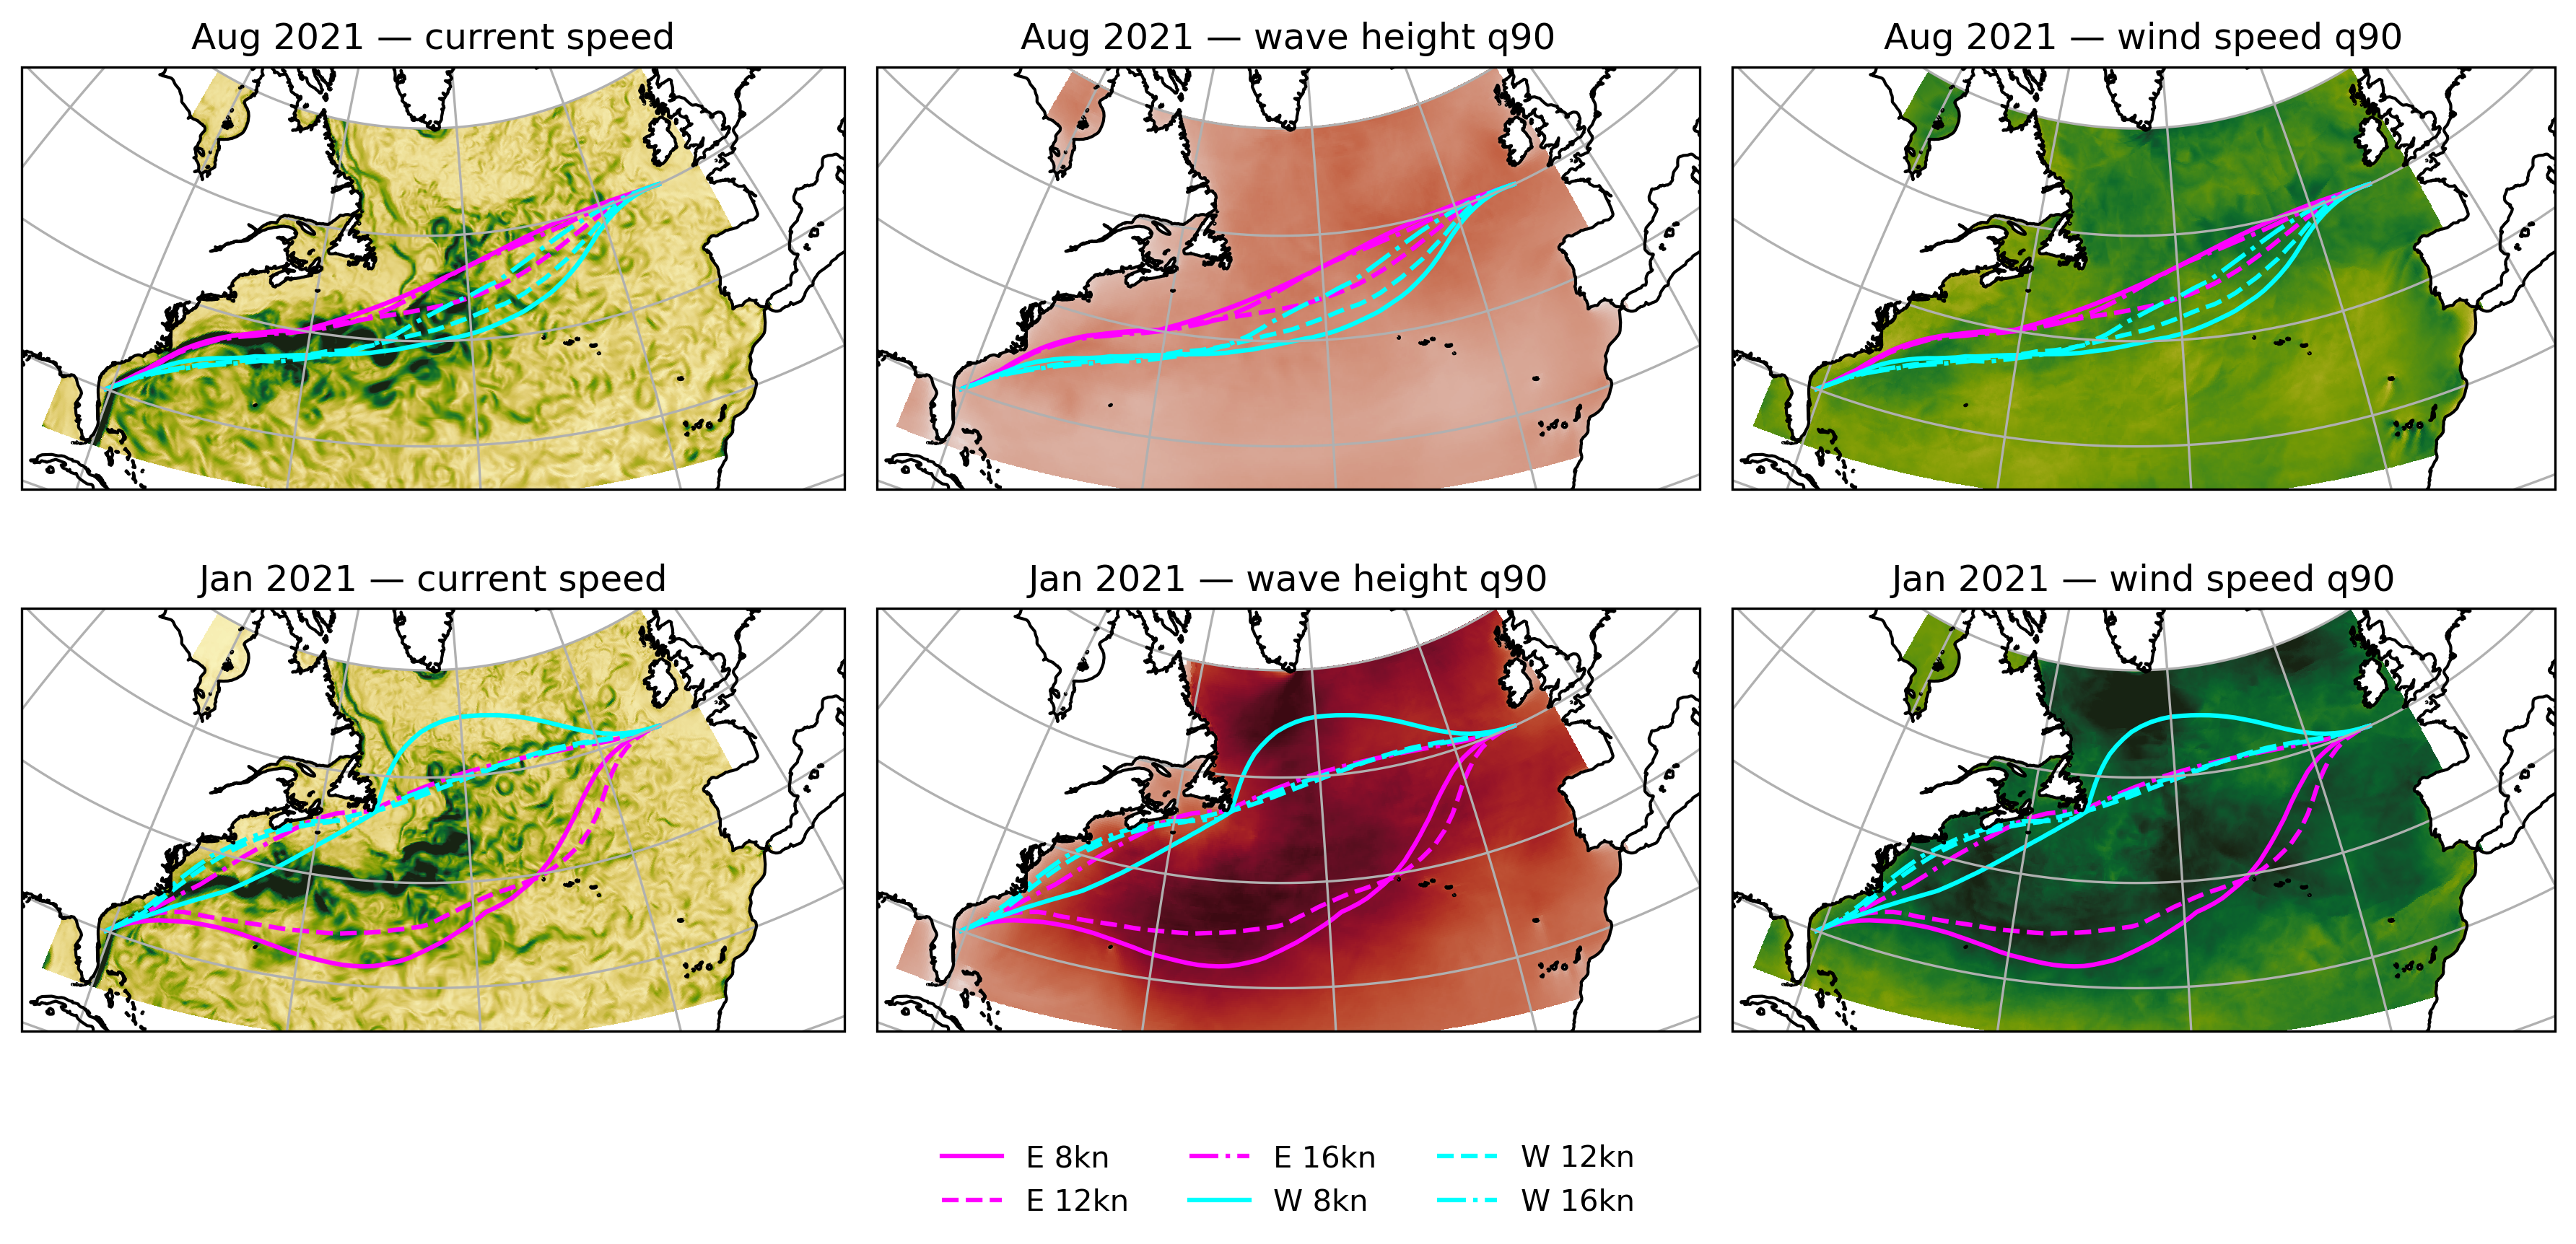

In [6]:
proj = cartopy.crs.Stereographic(
    central_latitude=LAT_CENT, central_longitude=LON_CENT
)
transform = cartopy.crs.PlateCarree()

MONTHS = [
    {"month": 8, "label": "Aug 2021"},
    {"month": 1, "label": "Jan 2021"},
]
ROUTE_STYLES = [
    {"direction": "eastward", "speed": 8, "color": "magenta", "ls": "-", "label": "E 8kn"},
    {"direction": "eastward", "speed": 12, "color": "magenta", "ls": "--", "label": "E 12kn"},
    {"direction": "eastward", "speed": 16, "color": "magenta", "ls": "-.", "label": "E 16kn"},
    {"direction": "westward", "speed": 8, "color": "cyan", "ls": "-", "label": "W 8kn"},
    {"direction": "westward", "speed": 12, "color": "cyan", "ls": "--", "label": "W 12kn"},
    {"direction": "westward", "speed": 16, "color": "cyan", "ls": "-.", "label": "W 16kn"},
]
COL_LABELS = ["current speed", "wave height q90", "wind speed q90"]

fig, axes = plt.subplots(
    len(MONTHS), 3,
    subplot_kw={"projection": proj},
    figsize=(3 * 4, len(MONTHS) * 3),
    sharex=True,
    sharey=True,
)
fig.set_dpi(300)

for i, minfo in enumerate(MONTHS):
    month_idx = minfo["month"] - 1

    # Current speed
    monthly_current_speed.isel(time=month_idx).plot(
        vmin=0, vmax=current_vmax, extend="max",
        cmap=cmocean.cm.speed, ax=axes[i, 0],
        transform=transform, rasterized=True, add_colorbar=False,
    )

    # Wave height q90
    monthly_wave_height.isel(time=month_idx).plot(
        vmin=0, vmax=wave_vmax, extend="max",
        cmap=cmocean.cm.amp, ax=axes[i, 1],
        transform=transform, rasterized=True, add_colorbar=False,
    )

    # Wind speed q90
    monthly_wind_speed.isel(time=month_idx).plot(
        vmin=0, vmax=wind_vmax, extend="max",
        cmap=cmocean.cm.speed, ax=axes[i, 2],
        transform=transform, rasterized=True, add_colorbar=False,
    )

    for j, col_label in enumerate(COL_LABELS):
        axes[i, j].set_title(f"{minfo['label']} \u2014 {col_label}")

    # Overlay all 4 routes for this month
    for rs in ROUTE_STYLES:
        month_short = minfo["label"].split()[0]
        key = f"{month_short} {rs['label']}"
        route = best_routes[key]
        for j in range(3):
            axes[i, j].plot(
                route["lons"], route["lats"],
                transform=transform,
                color=rs["color"], linestyle=rs["ls"],
                linewidth=1.5, label=rs["label"],
            )

    # Map features
    for j in range(3):
        axes[i, j].add_feature(cartopy.feature.LAND, facecolor="white", zorder=2)
        axes[i, j].coastlines(zorder=3)
        axes[i, j].gridlines(draw_labels=False)
        axes[i, j].set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

# Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:6], labels[:6], loc="lower center", ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(f"{FIG_DIR}/030_test_case_overview.png", dpi=150)
fig.savefig(f"{FIG_DIR}/030_test_case_overview.pdf", dpi=150)
plt.show()